# Appendix · Quantifying the shape of mean firing-rate traces

The chapter summarises each unit's temporal structure with a single number,
**Dominant-Peak Prominence (DPP)**. That is a deliberate simplification: DPP asks
only *"is there one tall peak with no comparable rival?"* and is silent about how
**wide** the response is and how **ragged** the trace is between peaks.

This appendix reports the fuller set of trace statistics, shows their distributions,
and establishes what DPP does and does not capture.

**Scope.** All panels use the **fixation-category-modulated** subpopulation only. A
width or raggedness statistic computed on an unmodulated trace describes the noise
floor rather than a response, so including those units would blur every distribution
towards the same shape.

Every figure is a single embeddable panel (one row of four regions), written as an
Illustrator-editable PDF and a 400 dpi PNG.

## A1 · Setup

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.ephys.plotting import thesis_common as style
from dal_monte_2022_analysis.ephys.plotting import thesis_single_unit as figs
from dal_monte_2022_analysis.ephys.plotting import thesis_single_unit_data as data
from dal_monte_2022_analysis.ephys.plotting import thesis_trace_metrics as metrics

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
PLOTTING_CFG_PATH = repo_root / "configs" / "plotting.yaml"
PSTH_CFG_PATH = repo_root / "configs" / "ephys_fixation_psth.yaml"

dataset_cfg = load_config(DATASET_CFG_PATH)
plotting_cfg = load_config(PLOTTING_CFG_PATH)
psth_cfg = load_config(PSTH_CFG_PATH)

style.apply_thesis_plot_style(plotting_cfg)
pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 60)

ANALYSIS_ROOT = data.resolve_psth_analysis_root(dataset_cfg)
FIGURE_SETTINGS = style.ThesisFigureSettings(output_dir=ANALYSIS_ROOT / "single_unit_thesis")
FIGURE_SETTINGS.output_dir.mkdir(parents=True, exist_ok=True)

FIGURE_MANIFEST: dict[str, dict[str, Path]] = {}

In [2]:
units = data.load_thesis_unit_table(ANALYSIS_ROOT)
selective = data.load_trace_metric_table(ANALYSIS_ROOT, units, selective_only=True)

exemplars = data.build_exemplar_table(units, data.parse_config_exemplar_map(psth_cfg))
exemplar_metrics = data.load_trace_metric_table(
    ANALYSIS_ROOT, exemplars, selective_only=False
)

FIGURE_SETTINGS = style.ThesisFigureSettings(
    output_dir=ANALYSIS_ROOT / "single_unit_thesis" / "appendix"
)
FIGURE_SETTINGS.output_dir.mkdir(parents=True, exist_ok=True)

print(f"{len(selective)} fixation-category-modulated units with trace metrics")
print(f"figures -> {FIGURE_SETTINGS.output_dir}")

574 fixation-category-modulated units with trace metrics
figures -> /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/single_unit_thesis/appendix


## A2 · The metrics

Each metric is computed on the condition-average firing-rate trace over −500 to
+500 ms, with the baseline taken as the 10th percentile of the in-window trace. They
are grouped by the property they measure, so it is clear which are alternative
estimates of the same thing and which are genuinely independent.

In [3]:
METRIC_ORDER = [
    "mass_width_frac_50",
    "effective_width_ms",
    "lifetime_sparseness",
    "peak_dominance",
    "n_prominent_peaks",
    "fwhm_frac",
    "sustained_frac",
    "roughness",
    "autocorr_width_ms",
    "peak_z",
]
definitions = metrics.build_metric_definition_table(METRIC_ORDER)
display(definitions)

,metric,axis,label,high value means
0,mass_width_frac_50,concentration,50% mass width (frac. of window),excess response spread over many bins (broad)
1,effective_width_ms,concentration,Effective width (ms),wide equivalent-rectangle response (broad)
2,lifetime_sparseness,concentration,Lifetime sparseness,excess mass concentrated in few bins (peaked)
3,peak_dominance,single_peak,Peak dominance (p1 / Σp),one peak carries most of the total prominence
4,n_prominent_peaks,single_peak,Prominent peaks (n),many comparable peaks (ragged)
5,fwhm_frac,sustainedness,FWHM (frac. of window),long time above half the excess peak (sustained)
6,sustained_frac,sustainedness,Sustained fraction (>25% excess),long time above 25% of the excess peak (sustai...
7,roughness,fluctuation,Roughness (total variation / range),many monotone excursions (fluctuating)
8,autocorr_width_ms,fluctuation,Autocorrelation half-width (ms),slowly varying trace (smooth)
9,peak_z,amplitude,Peak z (vs. window baseline),peak large relative to trace noise


## A3 · Distribution of each metric

One panel per metric, four regions per panel, with the chapter's high- and low-DPP
example units marked. Bin edges are shared across regions so the panel shapes can be
compared directly; the axis is trimmed at the 99.5th percentile because several
metrics have a thin right tail that would otherwise flatten the body.

**50% mass width
(frac. of window)**

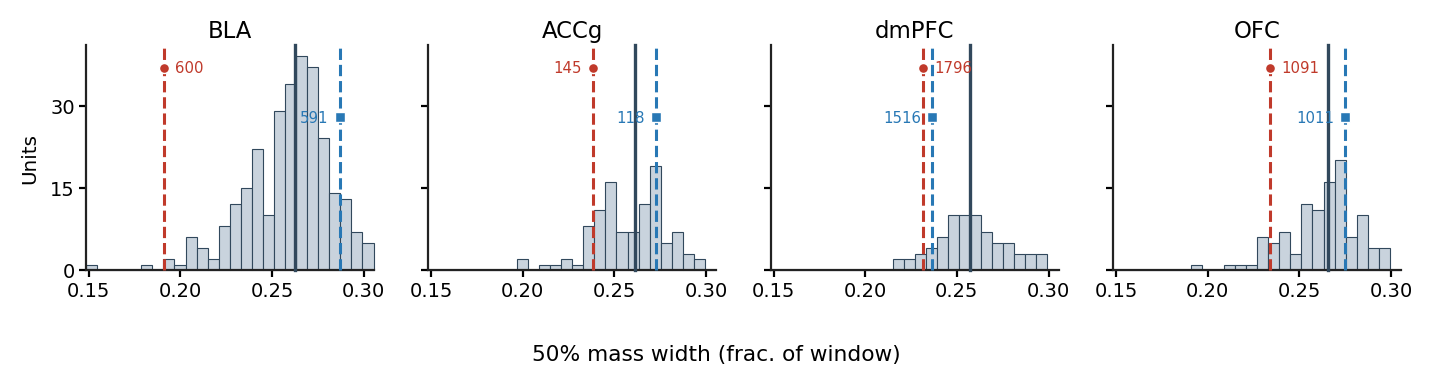

**Effective width (ms)**

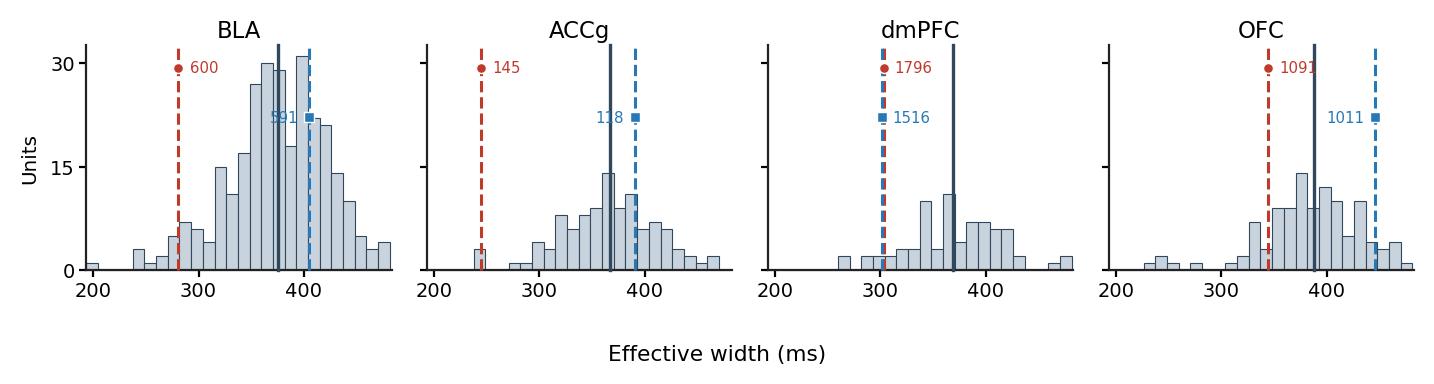

**Lifetime sparseness**

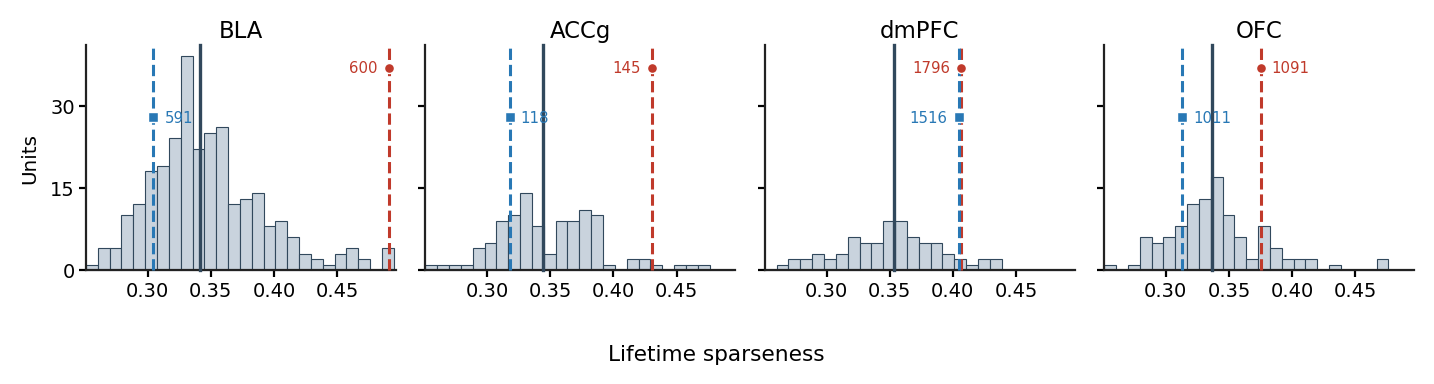

**Peak dominance $P_1/\Sigma P$**

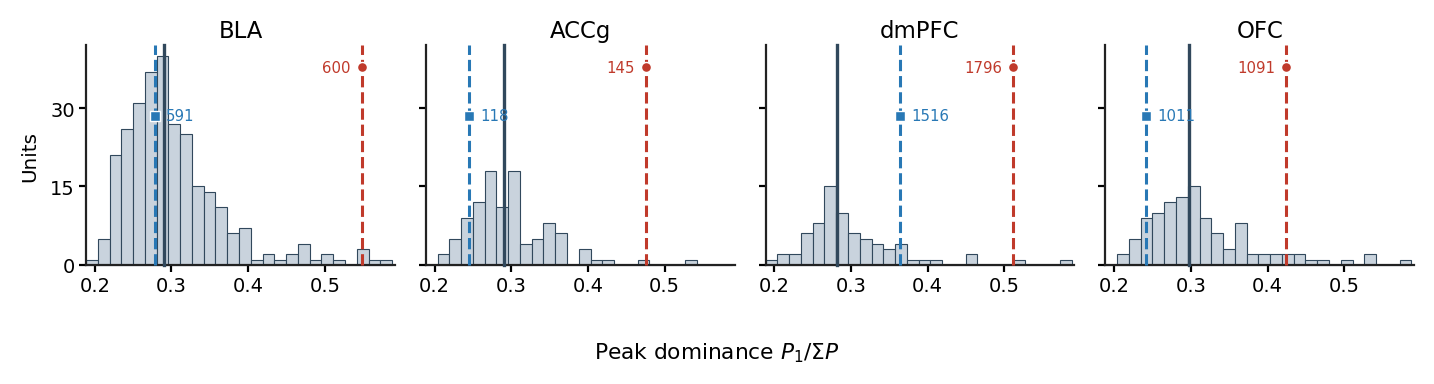

**Prominent peaks (n)**

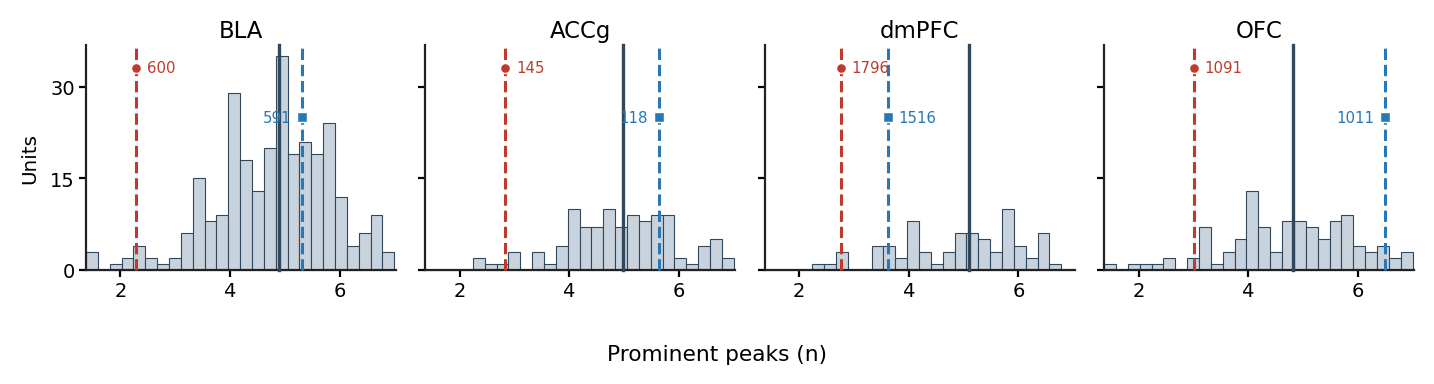

**FWHM (frac. of window)**

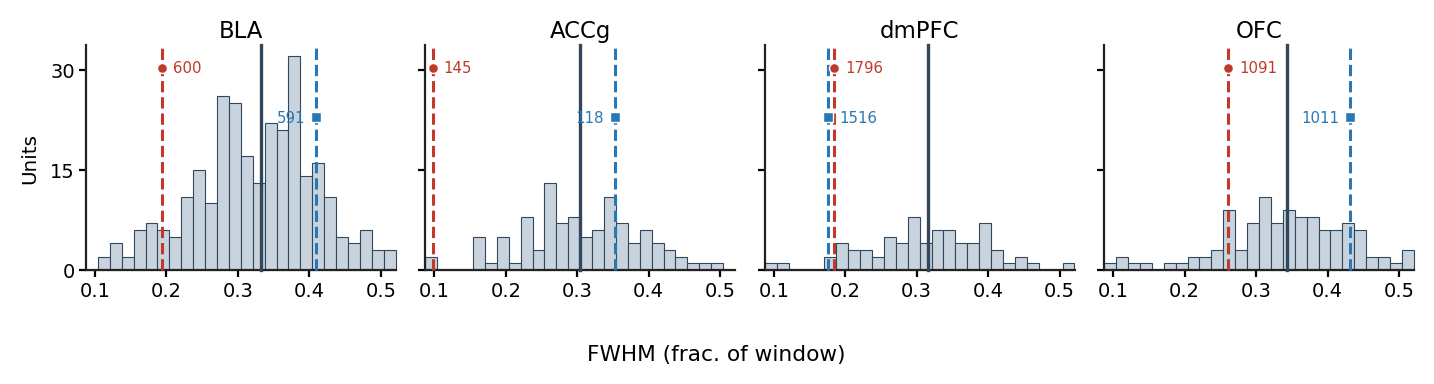

**Sustained fraction**

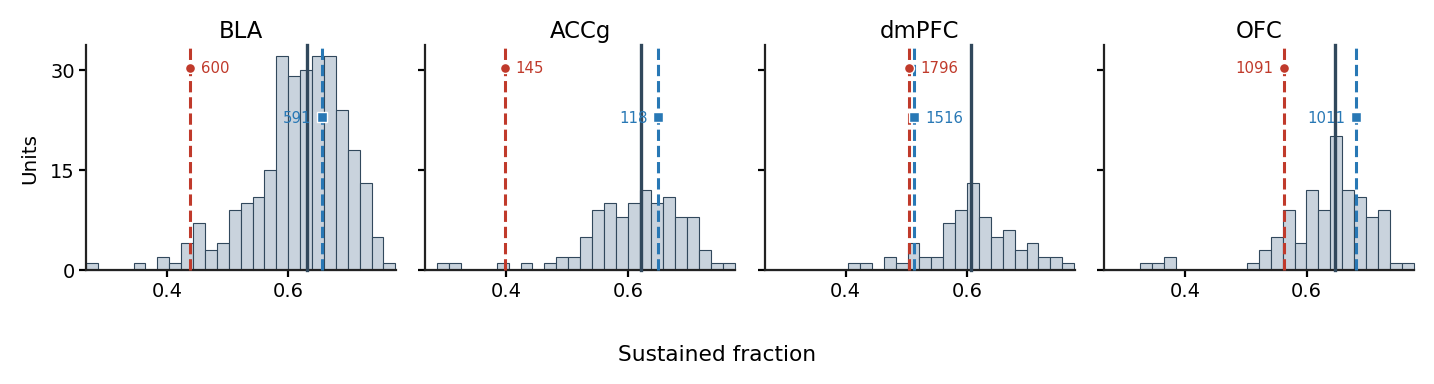

**Roughness (TV / range)**

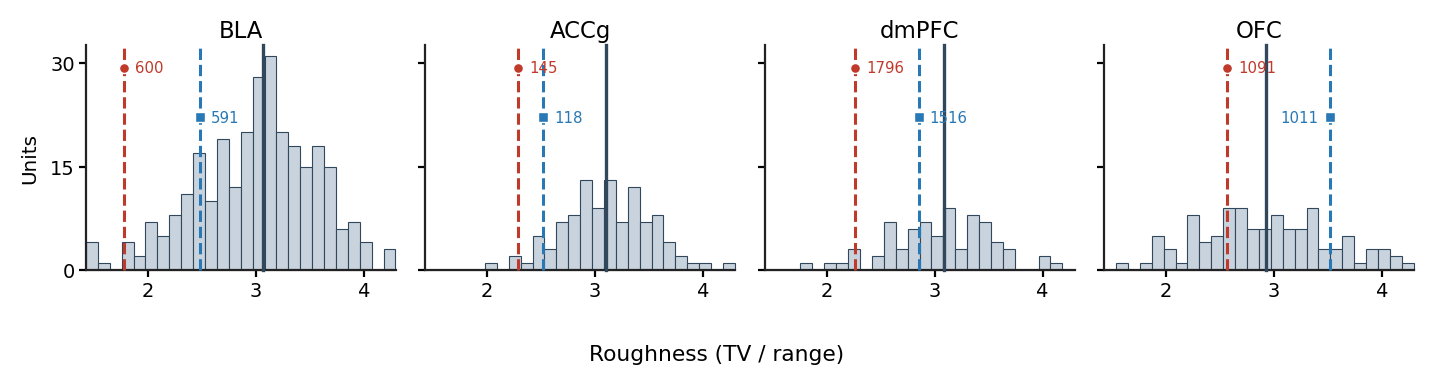

**Autocorr. half-width (ms)**

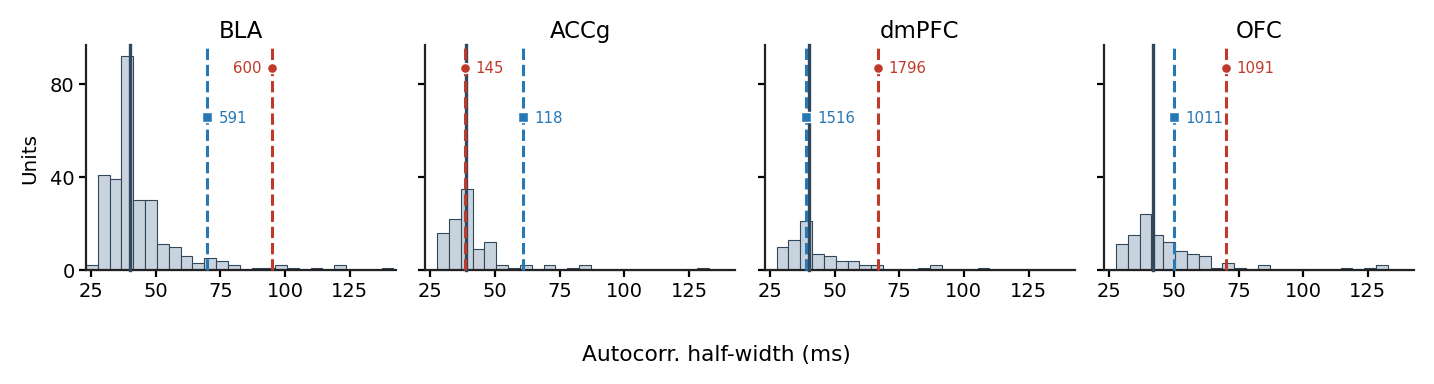

**Peak z (vs. baseline)**

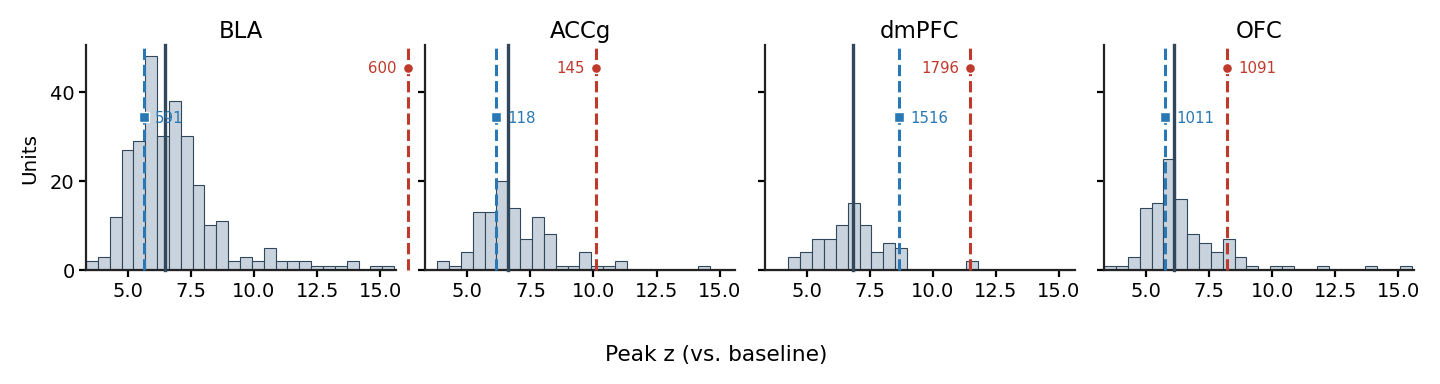

In [4]:
FIGURE_MANIFEST = {}
for index, metric in enumerate(METRIC_ORDER, start=1):
    fig = metrics.plot_metric_distribution_panel(
        selective, metric, exemplars=exemplar_metrics
    )
    stem = f"figA{index:02d}_{metric}"
    FIGURE_MANIFEST[stem] = style.save_thesis_figure(fig, FIGURE_SETTINGS, stem)
    display(Markdown(f"**{metrics.metric_axis_label(metric)}**"))
    display(Image(data=style.figure_to_png_bytes(fig)))

In [5]:
metric_summary = metrics.build_metric_summary_table(selective, metrics=METRIC_ORDER)
display(metric_summary.round(3))

,metric,label,region,n_units,median,q25,q75
0,mass_width_frac_50,50% mass width (frac. of window),BLA,287,0.263,0.245,0.274
1,mass_width_frac_50,50% mass width (frac. of window),ACCg,105,0.261,0.245,0.273
2,mass_width_frac_50,50% mass width (frac. of window),dmPFC,73,0.257,0.245,0.269
3,mass_width_frac_50,50% mass width (frac. of window),OFC,109,0.265,0.254,0.275
4,effective_width_ms,Effective width (ms),BLA,287,375.856,348.417,407.098
5,effective_width_ms,Effective width (ms),ACCg,105,366.586,337.636,394.065
6,effective_width_ms,Effective width (ms),dmPFC,73,368.620,340.235,399.590
7,effective_width_ms,Effective width (ms),OFC,109,388.032,361.471,415.113
8,lifetime_sparseness,Lifetime sparseness,BLA,287,0.341,0.319,0.373
9,lifetime_sparseness,Lifetime sparseness,ACCg,105,0.344,0.320,0.378


## A4 · Which metrics are redundant

Several of these measure the same underlying property by different routes. The
rank-correlation matrix below identifies those groups, so only one member of each
needs to be reported in the chapter.

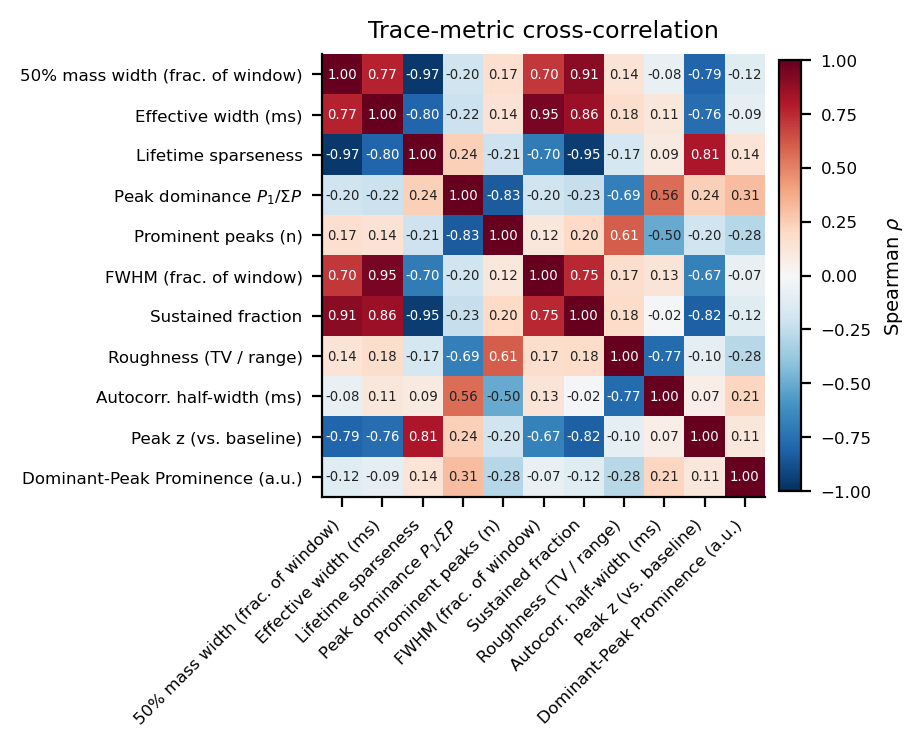

,mass_width_frac_50,effective_width_ms,lifetime_sparseness,peak_dominance,n_prominent_peaks,fwhm_frac,sustained_frac,roughness,autocorr_width_ms,peak_z,peakiness_score
mass_width_frac_50,1.00,0.77,-0.97,-0.20,0.17,0.70,0.91,0.14,-0.08,-0.79,-0.12
effective_width_ms,0.77,1.00,-0.80,-0.22,0.14,0.95,0.86,0.18,0.11,-0.76,-0.09
lifetime_sparseness,-0.97,-0.80,1.00,0.24,-0.21,-0.70,-0.95,-0.17,0.09,0.81,0.14
peak_dominance,-0.20,-0.22,0.24,1.00,-0.83,-0.20,-0.23,-0.69,0.56,0.24,0.31
n_prominent_peaks,0.17,0.14,-0.21,-0.83,1.00,0.12,0.20,0.61,-0.50,-0.20,-0.28
fwhm_frac,0.70,0.95,-0.70,-0.20,0.12,1.00,0.75,0.17,0.13,-0.67,-0.07
sustained_frac,0.91,0.86,-0.95,-0.23,0.20,0.75,1.00,0.18,-0.02,-0.82,-0.12
roughness,0.14,0.18,-0.17,-0.69,0.61,0.17,0.18,1.00,-0.77,-0.10,-0.28
autocorr_width_ms,-0.08,0.11,0.09,0.56,-0.50,0.13,-0.02,-0.77,1.00,0.07,0.21
peak_z,-0.79,-0.76,0.81,0.24,-0.20,-0.67,-0.82,-0.10,0.07,1.00,0.11


In [6]:
CORRELATION_METRICS = METRIC_ORDER + [style.DPP_COLUMN]
fig, correlation = metrics.plot_metric_correlation_panel(
    selective, metrics=CORRELATION_METRICS
)
FIGURE_MANIFEST["figA11_metric_correlation"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "figA11_metric_correlation"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(correlation.round(2))

## A5 · What DPP does and does not capture

Each panel plots one trace metric against DPP within region. A metric that tracks DPP
closely is redundant with it; one that is orthogonal describes a property of the same
trace that the chapter's single score discards.

**Peak dominance $P_1/\Sigma P$ vs DPP**

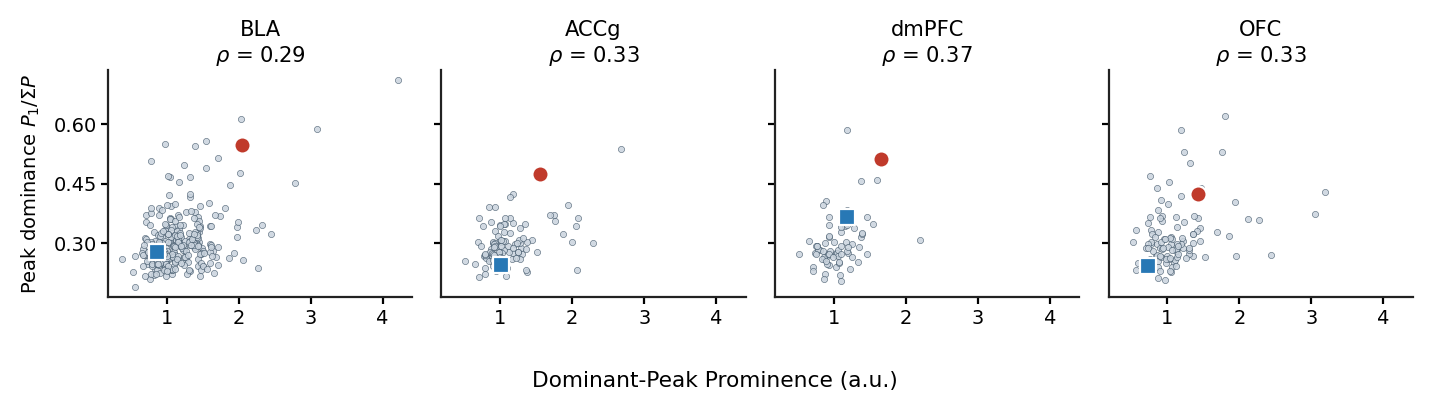

**FWHM (frac. of window) vs DPP**

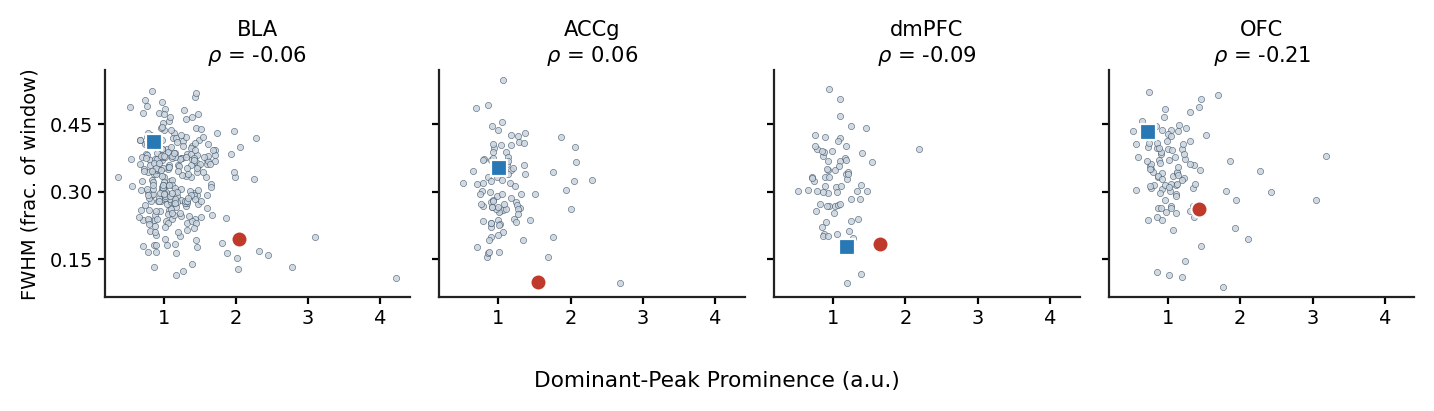

**Roughness (TV / range) vs DPP**

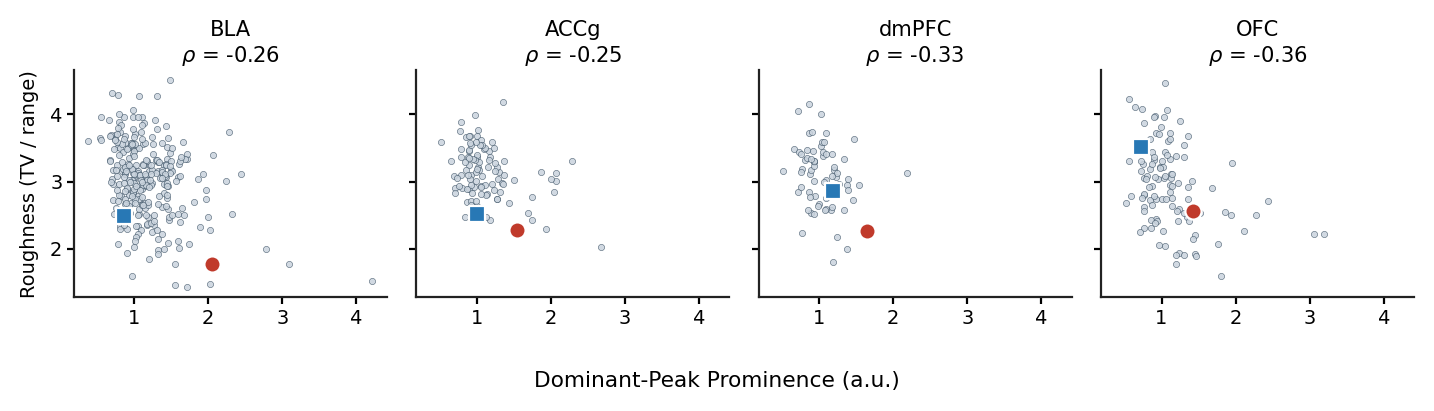

**Peak z (vs. baseline) vs DPP**

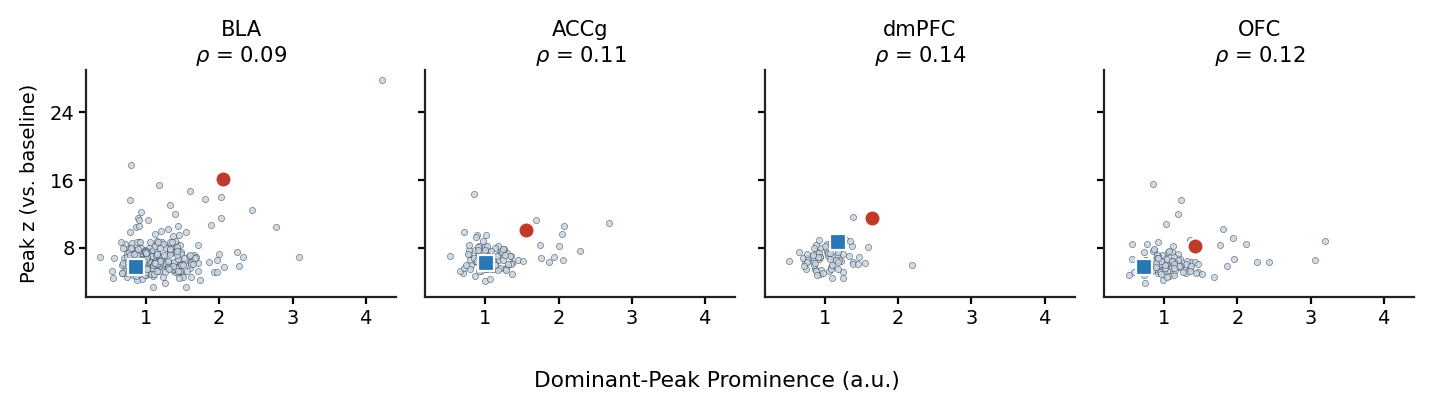

,region,metric,n_units,spearman_rho,p_value,p_adj
0,BLA,peak_dominance,287,0.2860,0.0000,0.0000
1,ACCg,peak_dominance,105,0.3317,0.0005,0.0007
2,dmPFC,peak_dominance,73,0.3736,0.0011,0.0011
3,OFC,peak_dominance,109,0.3264,0.0005,0.0007
4,BLA,fwhm_frac,287,-0.0558,0.3459,0.5340
5,ACCg,fwhm_frac,105,0.0614,0.5340,0.5340
6,dmPFC,fwhm_frac,73,-0.0864,0.4674,0.5340
7,OFC,fwhm_frac,109,-0.2083,0.0297,0.1188
8,BLA,roughness,287,-0.2571,0.0000,0.0000
9,ACCg,roughness,105,-0.2463,0.0113,0.0113


In [7]:
RELATIONSHIP_METRICS = ["peak_dominance", "fwhm_frac", "roughness", "peak_z"]
relationship_tables = []
for index, metric in enumerate(RELATIONSHIP_METRICS, start=12):
    fig, table = metrics.plot_metric_vs_dpp_panel(
        selective, metric, exemplars=exemplar_metrics
    )
    stem = f"figA{index:02d}_{metric}_vs_dpp"
    FIGURE_MANIFEST[stem] = style.save_thesis_figure(fig, FIGURE_SETTINGS, stem)
    display(Markdown(f"**{metrics.metric_axis_label(metric)} vs {style.DPP_ABBREV}**"))
    display(Image(data=style.figure_to_png_bytes(fig)))
    relationship_tables.append(table)

relationships = pd.concat(relationship_tables, ignore_index=True)
display(relationships.round(4))

## A6 · Where the example units fall on every metric

Percentile rank within each unit's own region. This is the audit of the chapter's
example selection: a high-DPP example should sit high on peak dominance and low on
the width measures, and a low-DPP example should do the opposite.

In [8]:
rank_table = metrics.build_exemplar_metric_rank_table(
    selective, exemplar_metrics, metrics=RELATIONSHIP_METRICS + ["mass_width_frac_50"]
)
display(rank_table.round(2))

,example,Region,Unit,Peak dominance $P_1/\Sigma P$,FWHM (frac. of window),Roughness (TV / range),Peak z (vs. baseline),50% mass width (frac. of window)
0,High DPP,BLA,600,0.98,0.08,0.03,0.99,0.01
1,Low DPP,BLA,591,0.40,0.85,0.17,0.25,0.91
2,High DPP,ACCg,145,0.99,0.02,0.02,0.96,0.11
3,Low DPP,ACCg,118,0.12,0.70,0.09,0.31,0.75
4,High DPP,dmPFC,1796,0.99,0.05,0.08,0.99,0.10
5,Low DPP,dmPFC,1516,0.86,0.04,0.33,0.93,0.12
6,High DPP,OFC,1091,0.91,0.17,0.30,0.88,0.10
7,Low DPP,OFC,1011,0.11,0.85,0.83,0.35,0.74


## A7 · Persist tables and figure manifest

In [9]:
exports = {
    "trace_metric_definitions.csv": definitions,
    "trace_metric_summary_by_region.csv": metric_summary,
    "trace_metric_correlation.csv": correlation.reset_index(names="metric"),
    "trace_metric_vs_dpp.csv": relationships,
    "exemplar_metric_percentiles.csv": rank_table,
}
for filename, frame in exports.items():
    frame.to_csv(FIGURE_SETTINGS.output_dir / filename, index=False)
    print(f"wrote {filename:40s} ({len(frame)} rows)")

print()
for stem in FIGURE_MANIFEST:
    print(stem)

wrote trace_metric_definitions.csv             (10 rows)
wrote trace_metric_summary_by_region.csv       (40 rows)
wrote trace_metric_correlation.csv             (11 rows)
wrote trace_metric_vs_dpp.csv                  (16 rows)
wrote exemplar_metric_percentiles.csv          (8 rows)

figA01_mass_width_frac_50
figA02_effective_width_ms
figA03_lifetime_sparseness
figA04_peak_dominance
figA05_n_prominent_peaks
figA06_fwhm_frac
figA07_sustained_frac
figA08_roughness
figA09_autocorr_width_ms
figA10_peak_z
figA11_metric_correlation
figA12_peak_dominance_vs_dpp
figA13_fwhm_frac_vs_dpp
figA14_roughness_vs_dpp
figA15_peak_z_vs_dpp


## Appendix summary

- The metrics fall into a small number of correlated groups (A4): width measures
  (`mass_width_frac_50`, `effective_width_ms`, `fwhm_frac`, `sustained_frac`,
  `lifetime_sparseness`) are largely interchangeable, as are the two composites.
  `roughness` and `peak_dominance` carry information the width measures do not.
- **DPP measures peak isolation, not response width** (A5). Its strongest
  association is with `peak_dominance` (rho approximately 0.3) and its next with
  `roughness` and the prominent-peak count (both approximately -0.3); it is close to
  independent of every width measure (|rho| < 0.15 against `mass_width_frac_50`,
  `effective_width_ms`, `fwhm_frac` and `sustained_frac`). The chapter's single score
  should therefore not be described as measuring how *narrow* a response is - it says
  a peak stands alone, not that it is brief. Note also that no single metric explains
  DPP: even the strongest correlation is modest, because DPP combines peak height and
  rival suppression in a way none of the individual statistics reproduces.
- The high-DPP example units rank at the top of their region on peak dominance and at
  the bottom on the width measures, as their label claims (A6). Among the low-DPP
  examples, **dmPFC 1516 does not**: it ranks high on peak dominance and low on FWHM,
  behaving like a high-DPP unit on the shape metrics even though its DPP score is
  only mid-range. Its high `roughness` is what holds its DPP down.